In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from utils import compute_itc

In [2]:
n_source = 50

data_dir = "/data/users4/xli/MSIVA/MSIVA/results/mat"
x_ukb = sio.loadmat(f"{data_dir}/sMRI-fMRI/X_ukb.mat")['X']
x_ukb = np.squeeze(x_ukb)
x_ukb_list = [x_ukb[m] for m in range(len(x_ukb))]

x_sz = sio.loadmat(f"{data_dir}/sMRI-fMRI/X_sz.mat")['X']
x_sz = np.squeeze(x_sz)
id = sio.loadmat(f"{data_dir}/SZID.mat")['ID'][0] - 1
x_sz_list = [x_sz[m][:,id] for m in range(len(x_sz))]

aic_ukb, kic_ukb, mdl_ukb = compute_itc(x_ukb_list, n_source)
aic_sz, kic_sz, mdl_sz = compute_itc(x_sz_list, n_source)

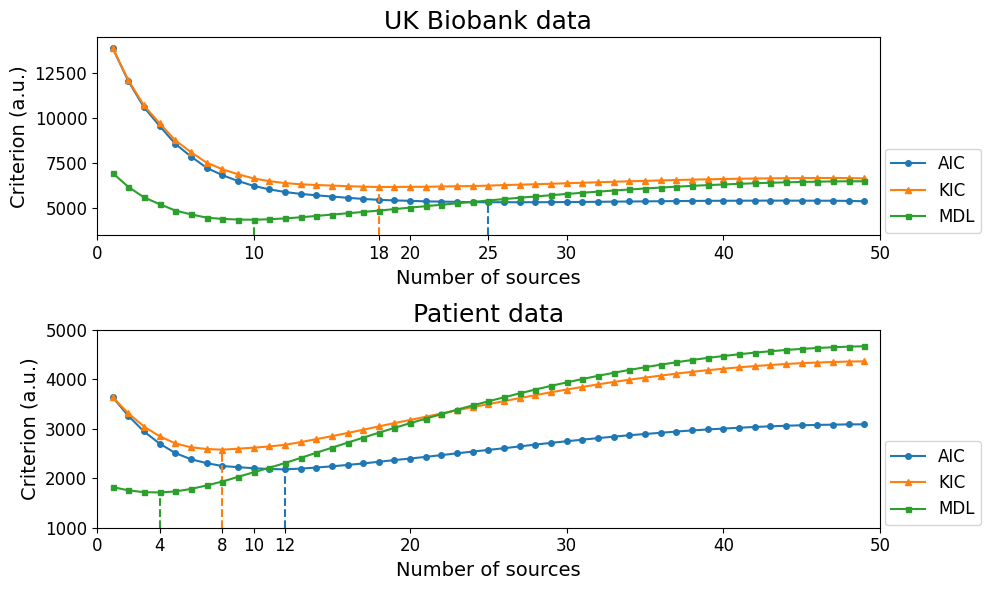

In [ ]:
info_criteria = [[aic_ukb, kic_ukb, mdl_ukb], [aic_sz, kic_sz, mdl_sz]]
dataset_list = ['UK Biobank', 'Patient']
ylim_list = [[3500, 14500], [1000, 5000]]

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

for i in range(2):
    ax = axes[i]
    ax.axvline(x = np.argmin(info_criteria[i][0])+1, ymin = 0, ymax = (np.min(info_criteria[i][0])-ylim_list[i][0])/(ylim_list[i][1]-ylim_list[i][0]), color='C0', ls='--')
    ax.plot(range(1, n_source), info_criteria[i][0], 'o-', label='AIC', color='C0', ms=4)

    ax.axvline(x = np.argmin(info_criteria[i][1])+1, ymin = 0, ymax = (np.min(info_criteria[i][1])-ylim_list[i][0])/(ylim_list[i][1]-ylim_list[i][0]), color='C1', ls='--')
    ax.plot(range(1, n_source), info_criteria[i][1], '^-', label='KIC', color='C1', ms=4)
    
    ax.axvline(x = np.argmin(info_criteria[i][2])+1, ymin = 0, ymax = (np.min(info_criteria[i][2])-ylim_list[i][0])/(ylim_list[i][1]-ylim_list[i][0]), color='C2', ls='--')
    ax.plot(range(1, n_source), info_criteria[i][2], 's-', label='MDL', color='C2', ms=3.6)

    ticks = list(set(list(range(0, n_source+1, 10))+[np.argmin(info_criteria[i][j])+1 for j in range(3)])) # apply set to remove duplicates
    ticks.sort()
    ax.set_xticks(ticks, ticks)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_xlabel('Number of sources', fontsize=14)
    ax.set_ylabel('Criterion (a.u.)', fontsize=14)
    ax.set_title(f'{dataset_list[i]} data', fontsize=18)
    ax.set_xlim([0, n_source])
    ax.set_ylim(ylim_list[i])
    ax.legend(bbox_to_anchor=(1.14, 0.48), fontsize=12)

plt.tight_layout()
plt.savefig('figures/order_selection.pdf')